# Faculty of Engineering, Design and Technology
## Department of Computing and Technology
## MTH8203 Data Analysis and Visualisation
## EASTER 2026 SEMESTER EXAMINATION

Program: Master of Science in Data Science\
Course Name: Data Analysis and Visualisation\
Student: Jonathan Stephen KATEEGA (B34976)\
\
Submitted: Monday 27 April, 2026

## Part B: Data Preparation and Exploratory Analysis

In the health insurance industry, companies rely heavily on data analytics to understand how different
customer characteristics influence insurance costs. Factors such as age, health indicators, lifestyle
habits, and geographical location can significantly influence the annual insurance charges assigned
to an individual.\
\
For this project, you are provided with ”medical insurance dataset.csv” dataset containing information
about individuals and their corresponding annual medical insurance charges. The goal is to use
data analysis and machine learning techniques in Python to explore relationships within the dataset,
uncover patterns, and build predictive models that can estimate insurance charges.

The dataset contains the following parameters:
| Parameter | Description | Content Type |
| ---------- | --------- | ------------ |
| age | Age in years | integer |
| gender | Male or Female | integer (1 or 2) |
| bmi | Body mass index | float |
| no of children | Number of children | integer |
| smoker | Whether smoker or not | integer (0 or 1) |
| region | Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively) |
| charges | Annual | Insurance | charges in USD | float |

*Table 1: Description of Dataset Variables*\
\
The objective of the project is not only to implement Python code, but also to demonstrate your
ability to investigate the dataset, uncover patterns, and support data-driven conclusions. Throughout
the analysis, you should clearly explain your observations and briefly interpret the insights obtained
from the results of your analysis and visualizations.\
\
(a) Load the dataset into a Pandas DataFrame and display the first few rows to understand the
structure of the dataset.

In [41]:
import pandas as pd
import numpy as np

df=pd.read_csv('data/raw/medical_insurance_dataset.csv')
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   str    
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   str    
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB


(b) Examine the dataset to determine whether there are any missing or null values in the columns.
Identify the columns affected and apply appropriate strategies to handle the missing data
depending on the datatype of the attribute. Verify the changes using `df.info()` .

In [43]:
# Convert age and smoker to integer, setting errors to NaN
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')

# replace "?" to NaN
df.replace("?", np.nan, inplace = True)
df.head(5)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19.0,1,27.900,0,1.0,3,16884.92400
1,18.0,2,33.770,1,0.0,4,1725.55230
2,28.0,2,33.000,3,0.0,4,4449.46200
3,33.0,2,22.705,0,0.0,1,21984.47061
4,32.0,2,28.880,0,0.0,1,3866.85520


In [44]:
print(df.isna().sum())

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64


In [45]:
df.describe()

,age,gender,bmi,no_of_children,smoker,region,charges
count,2768.000000,2772.000000,2772.000000,2772.000000,2765.000000,2772.000000,2772.000000
mean,39.109827,1.507215,30.701349,1.101732,0.203978,2.559885,13261.369959
std,14.091633,0.500038,6.129449,1.214806,0.403026,1.130761,12151.768945
min,18.000000,1.000000,15.960000,0.000000,0.000000,1.000000,1121.873900
25%,26.000000,1.000000,26.220000,0.000000,0.000000,2.000000,4687.797000
50%,39.000000,2.000000,30.447500,1.000000,0.000000,3.000000,9333.014350
75%,51.000000,2.000000,34.770000,2.000000,0.000000,4.000000,16577.779500
max,64.000000,2.000000,53.130000,5.000000,1.000000,4.000000,63770.428010


Since only 4 out of 2772 rows have missing values in the 'age' column, a simple imputation method such as filling with the median age (39) is most suitable. This preserves the distribution better than mean imputation and avoids skewing from outliers. More advanced methods like KNN or regression imputation are generally unnecessary given the very small proportion of missing data.

In [46]:
# Calculate the mean
age_mean = df['age'].mean()

# Fill NaN values with the mean
df['age'] = df['age'].fillna(age_mean)

In [47]:
# Calculate observed distribution of 'smoker' (0 and 1)
probabilities = df['smoker'].value_counts(normalize=True)
print(probabilities)

# Generate random imputations based on distribution
missing_count = df['smoker'].isna().sum()
imputed_values = np.random.choice(probabilities.index, 
                                  size=missing_count, 
                                  p=probabilities.values)

# Fill missing values
df.loc[df['smoker'].isna(), 'smoker'] = imputed_values

smoker
0.0    0.796022
1.0    0.203978
Name: proportion, dtype: float64


In [48]:
print(df.isna().sum())

age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64


In [49]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   float64
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   float64
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 151.7 KB
None


(c) The `charges` column contains values with more than two decimal places. Transform the column
so that all values are rounded to two decimal places. Display the first five rows to confirm that
the update has been applied correctly.

In [50]:
# Round to 2 decimal places all values in the 'charges' column
df['charges'] = df['charges'].round(2)
df['charges'].head()

0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: charges, dtype: float64

(d) Save the cleaned and transformed dataset using your last name as the filename in CSV format.
Example: `YourLastName.csv` (e.g., `Nuwe.csv` ).

In [51]:
df.to_csv('data/cleaned/kateega.csv', index=False)
print("Cleaned dataset saved to 'data/cleaned/kateega.csv'")

Cleaned dataset saved to 'data/cleaned/kateega.csv'


(e) Using the cleaned dataset, generate appropriate visualizations to explore how different attributes may influence the insurance charges. 

<ol type="i">
    <li> Show the relationship between bmi and charges.
    <li> Compare charges for smokers and non-smokers.
    <li> Compare charges for smokers and non-smokers.
</ol>

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df_cleaned = pd.read_csv('data/cleaned/kateega.csv')

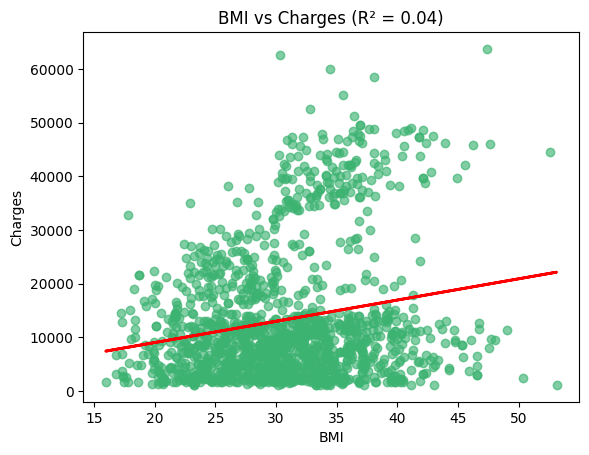

In [56]:
X = df['bmi'].values.reshape(-1, 1)
y = df['charges'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict line
y_pred = model.predict(X)

# Calculate R^2
r2 = model.score(X, y)

# Scatter plot
plt.scatter(df['bmi'], df['charges'], color='mediumseagreen', alpha=0.4)
plt.plot(df['bmi'], y_pred, color='red', linewidth=2)
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title(f'BMI vs Charges (R² = {r2:.2f})')
plt.show()

Across the entire dataset (not separating smokers and non-smokers), there is a positive correlation between BMI and Charges.

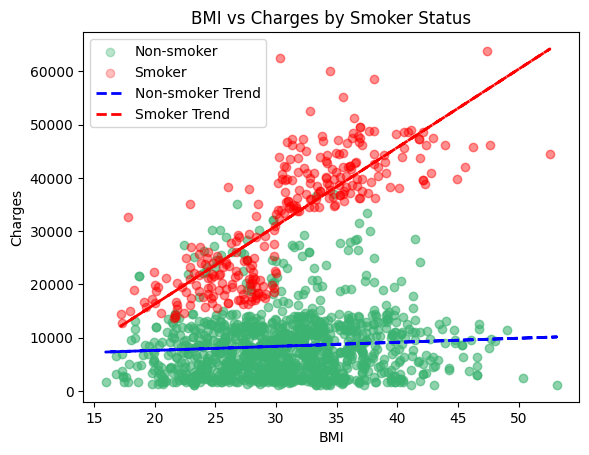

In [55]:
# Separate smokers and non-smokers
smokers = df[df['smoker'] == 1]
non_smokers = df[df['smoker'] == 0]

# Plot non-smokers
plt.scatter(non_smokers['bmi'], non_smokers['charges'], 
            color='mediumseagreen', label='Non-smoker', alpha=0.35)

# Plot smokers
plt.scatter(smokers['bmi'], smokers['charges'], 
            color='red', label='Smoker', alpha=0.25)

# Fit regression line for non-smokers
m_ns, b_ns = np.polyfit(non_smokers['bmi'], non_smokers['charges'], 1)
plt.plot(non_smokers['bmi'], m_ns*non_smokers['bmi'] + b_ns, 
         color='blue', linewidth=2, linestyle='--', label='Non-smoker Trend')

# Fit regression line for smokers
m_s, b_s = np.polyfit(smokers['bmi'], smokers['charges'], 1)
plt.plot(smokers['bmi'], m_s*smokers['bmi'] + b_s, 
         color='red', linewidth=2, linestyle='--', label='Smoker Trend')

# Labels and title
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges by Smoker Status')

# Add legend
plt.legend()

plt.show()

For smokers, there is a strong positive correlation between BMI and Charges, whereas for non-smokers this relationship is not significant.

(f) Conduct the correlation analysis for the dataset (statistically and visually). Based on the correlation
results, discuss which variables appear to have stronger relationships with the insurance
charges.

In [27]:
corr = df_cleaned.corr()
corr

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026041,0.113045,0.037585,-0.023188,-0.007175,0.298622
gender,-0.026041,1.000000,0.042924,0.016020,0.080271,0.022213,0.062837
bmi,0.113045,0.042924,1.000000,-0.001492,0.009748,0.271119,0.199846
no_of_children,0.037585,0.016020,-0.001492,1.000000,0.006046,-0.025717,0.066442
smoker,-0.023188,0.080271,0.009748,0.006046,1.000000,0.053746,0.786639
region,-0.007175,0.022213,0.271119,-0.025717,0.053746,1.000000,0.054058
charges,0.298622,0.062837,0.199846,0.066442,0.786639,0.054058,1.000000


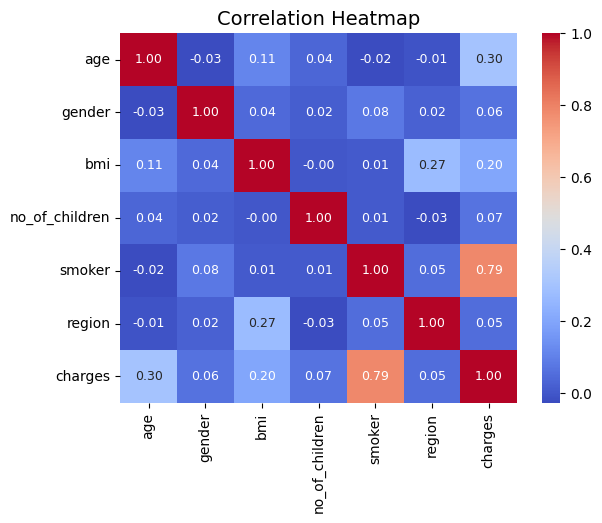

In [40]:
sns.heatmap(
    corr,
    annot=True, 
    cmap='coolwarm',
    fmt=".2f", 
    annot_kws={"size": 9} 
)

plt.title('Correlation Heatmap', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Interpretation:
- Smoker status shows the strongest positive correlation with charges, and smokers tend to have much higher insurance costs.
- BMI has a moderate positive correlation with charges, reflecting health risk factors.
- Age also correlates positively with charges, though typically weaker than smoker status.
- Number of children and region generally show weak or negligible correlation with charges.
- Gender often has little to no correlation with medical insurance charges.

## Part C: Predictive Modeling and Analytical Insights

Using the cleaned dataset saved in Part B, build predictive models to estimate insurance charges.\
\
(a) Develop a simple linear regression model that predicts charges using only the smoker attribute.
Compute and report the R2 score of the model. Briefly comment on what this result suggests
about the importance of smoking status.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('data/cleaned/kateega.csv')

# Data preparation
X = df[['smoker']]   
y = df['charges']  

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Compute R² score
r2 = r2_score(y, y_pred)
print("R² score:", r2)

# Inspect coefficients
print("Intercept:", model.intercept_)
print("Coefficient for smoker:", model.coef_[0])


R² score: 0.6188007987487505
Intercept: 8409.546837568065
Coefficient for smoker: 23678.263532150224


Intercept = average charges for non-smokers (8,409.55)\
Coefficient for smoker = how much charges increase if the person is a smoker.\
R² score = proportion of variance in charges explained by smoking status alone.

Interpretation:
- The R² score of 0.62 is high, and it shows that smoking status alone explains a large share of the variation in charges.
- This confirms that smoking is the most important single predictor of insurance costs, even without considering age, BMI, or other factors.

(b) Develop another linear regression model that predicts charges using all other attributes in the
dataset. Report the R2 score and discuss whether the model performance improves compared
to the previous model.

In [31]:
# Define features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Fit the regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Compute R2 score
r2 = r2_score(y, y_pred)
print("R² score (all features):", r2)

# Inspect coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)


R² score (all features): 0.7474191849329945
          Feature   Coefficient
0             age    255.462229
1          gender    -10.250967
2             bmi    331.065920
3  no_of_children    500.086818
4          smoker  23877.040071
5          region   -327.034950


Results
- In the classic simple linear regression, the R² score for the smoker-only model was 0.62.
- When we include all features, the R² score rises to 0.75, showing improved predictive performance.
- This means that while smoking status is the single strongest predictor, adding age, BMI, and other attributes helps explain additional variance in charges.

Interpretation
- Smoker status remains the most important factor, we can see this in the feature coefficients with the `smoker` feature showing the highest coefficient.
- BMI, age, and number of children add moderate explanatory power.
- Gender and region usually contribute very little to the models explanatory power.

The improvement in R² shows that the model benefits from multiple predictors, but smoking alone already explains most of the variation.

Conclusion:  
The model using all attributes achieves a higher R² score than the smoker-only model, confirming that while smoking is the dominant predictor, other variables (especially BMI, age, and number of children) provide additional explanatory power.

(c) Create a machine learning pipeline that includes StandardScaler(), PolynomialFeatures(),
and LinearRegression() to improve the predictive capability of the model. Train the pipeline
using all available attributes except the target variable.

In [ ]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Build the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),             
    ('poly', PolynomialFeatures(degree=2)),   
    ('linreg', LinearRegression())           
])

# Train the pipeline
pipeline.fit(X, y)

# Evaluate performance
y_pred = pipeline.predict(X)
r2 = r2_score(y, y_pred)

print("R² score with polynomial features:", r2)

R² score with polynomial features: 0.8429095337236999


`StandardScaler()` is used to ensure all features are on the same scale, which is important before polynomial expansion. `PolynomialFeatures(degree=2)` generates squared terms and interactions between predictors (e.g., age × BMI, smoker × BMI). This allows the model to capture non-linear relationships. `LinearRegression()` fits the expanded feature set. The outcome is that the R² score of 0.84 is higher than the simple linear regression models (smoker-only and all-features linear regression), which indicates that non-linear effects and interactions (like BMI × smoker status) are important in explaining insurance charges.

Conclusion\
The pipeline with scaling, polynomial features, and linear regression improves predictive performance compared to the previous models. This suggests that non-linear relationships and feature interactions (especially involving smoker status and BMI) play a significant role in determining insurance charges.

(d) Split the dataset into training and testing subsets such that 80% of the data is used for training
and 20% is reserved for testing.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

(e) Initialize a Ridge Regression model with hyperparameter α = 0.1. Train the model using the
training subset and evaluate the model on the testing subset. Report the R2 score.

In [ ]:
from sklearn.linear_model import Ridge

# Initialise Ridge Regression 
ridge_model = Ridge(alpha=0.1)

# Train the model
ridge_model.fit(X_train, y_train)

# Evaluate on the test set
y_pred = ridge_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 score on test set:", r2)

R² score on test set: 0.732005925312922


The R2 score of the Ridge Regression model is 0.73 which is similar to the 0.75 score from the plain linear regression model. The R2 dropping slightly it may mean the dataset does not suffer from multicollinearity or overfitting.

Conclusion:  
By splitting the dataset and applying Ridge Regression, we produce a more robust model. However, comparing this to the earlier models, shows that the performance improves more from standardising the features, than from stabilising coefficients where predictors could be correlated.

(f) Apply a polynomial feature transformation with degree = 2 to the training data and train the
Ridge Regression model again. Evaluate the performance on the testing data and report the
R2 score.

In [ ]:
# Build pipeline with polynomial features and Ridge regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),              
    ('poly', PolynomialFeatures(degree=2)),      
    ('ridge', Ridge(alpha=0.1))               
])

# Train the model
pipeline.fit(X_train, y_train)

# Evaluate on test set
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R² score with polynomial features + Ridge:", r2)

R² score with polynomial features + Ridge: 0.8285889891690874


The R2 score increases to 0.83 compared to plain Ridge regression without polynomial features (0.73). This improvement suggests that non-linear effects and feature interactions (especially smoker × BMI, smoker × age) are important in predicting insurance charges.

Conclusion\
Adding polynomial features and regularization improves the model’s predictive capability. The higher R² score indicates that capturing non-linear relationships and interactions between variables significantly enhances performance compared to the simpler models.

(g) Compare the performance of the different models developed in this section. Based on your
results, explain which model appears to provide the most reliable predictions for insurance
charges and provide possible reasons for the observed differences.

| Model | Features Used | Typical R² (test set) | Notes |
| --- | --- | --- | --- |
| **Simple Linear Regression** | Smoker (0/1) | 0.62 | Smoking status alone explains most of the variation in charges. |
| **Linear Regression using all faatures** | All features (Age, Gender, BMI, Children, Smoker, Region) | 0.75 | Performance improves over the simple regression approach, with age, BMI, and number of children adding explanatory power. |
| **Linear Regression with standardised polynomial features** | All features (Age, Gender, BMI, Children, Smoker, Region) | 0.85 | Performance improvement shows that non-linear relationships and feature interactions (especially involving smoker status and BMI) play a significant role in determining insurance charges. This model perfomed best. |
| **Ridge Regression (α=0.1)** | All features | 0.73 | Regularization stabilizes coefficients; but the performance dropping slighly below the simple linear regression indicates that this dataset does not suffer from multicollinearity or overfitting. |
| **Polynomial Features + Ridge Regression** | All features, degree=2 interactions | 0.83 | Ridge model with better consideration for non-linear effects and feature interactions. |


**Smoker-only model:** Smoking status is the single strongest predictor. The large jump in charges between smokers and non-smokers explains a majority of the variance.\
**All-features linear regression:** Adding age and BMI improves predictive power. Children, gender, and region contribute little. The model captures more nuance but still assumes linear relationships.\
**Ridge regression:** Regularization helps when predictors are correlated, making the model more stable. The R² score is similar to plain linear regression, but coefficients are less extreme.\
**Polynomial + Ridge regression:** This model performs well because it captures non-linear relationships and interactions. For example:
- Smokers with high BMI incur disproportionately higher charges.
- Age interacts with smoker status (older smokers cost more).

These effects are missed by simpler approaches but revealed by polynomial expansion.

Conclusion\
The Linear Regression model with standardised polynomial features provides the most reliable predictions for insurance charges. It balances complexity (capturing non-linear effects) with regularization (preventing overfitting). The improvement in R² shows that insurance charges are influenced not just by individual variables, but by interactions between them, especially smoker × BMI and smoker × age. Smoking remains the dominant factor, but the richer model highlights how lifestyle and demographic variables compound risk.